In [1]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from noisemodel import*
from codewords import*
from optimisation import*
import matplotlib.pyplot as plt

I think the first thing to do before any experiment is to verify if the optimisation is giving us the correct output. Experiment the 4-qubit code against amplitude damping noise.

In [23]:
def four_qubit(*, return_qutip: bool = True):
    """
    4-qubit code (full Hilbert space, not symmetric subspace).
    
    Codewords:
      |0_L> = (|0000> + |1111>)/√2
      |1_L> = (|0011> + |1100>)/√2
    
    Returns: (rho, l0, l1) either as qutip.Qobj or numpy arrays
    """
    n = 4
    dim = 2**n
    
    def idx_from_bitstr(bitstr: str) -> int:
        """Convert binary string to 1-based index (MATLAB style) then to 0-based."""
        return int(bitstr, 2)  # 0-based indexing in Python
    
    # |0_L>
    ket0L = np.zeros(dim, dtype=complex)
    ket0L[idx_from_bitstr('0000')] = 1/np.sqrt(2)
    ket0L[idx_from_bitstr('1111')] = 1/np.sqrt(2)
    
    # |1_L>
    ket1L = np.zeros(dim, dtype=complex)
    ket1L[idx_from_bitstr('0011')] = 1/np.sqrt(2)
    ket1L[idx_from_bitstr('1100')] = 1/np.sqrt(2)
    
    # Normalize (already normalized, but for safety)
    ket0L = ket0L / np.linalg.norm(ket0L)
    ket1L = ket1L / np.linalg.norm(ket1L)
    
    # Create maximally mixed state on codespace
    #rho = code_maximally_mixed_on_codespace(ket0L, ket1L)
    rho = 0.5* (np.outer(ket0L, ket0L.conj()) + np.outer(ket1L, ket1L.conj()))
    
    # Reshape to column vectors
    l0 = ket0L.reshape(-1, 1)
    l1 = ket1L.reshape(-1, 1)
    
    if return_qutip:
        return as_qutip_objects(rho, l0, l1)
    return rho, l0, l1
def local_ampdamp(gamma: float, dim: int) -> List[np.ndarray]:
    """
    Generate Kraus operators for local amplitude damping noise on N qubits.
    
    Args:
        gamma: Damping parameter in [0, 1]
        dim: Hilbert space dimension (must be 2^N for some integer N)
    
    Returns:
        List of Kraus operators (numpy arrays)
    """
    # Validate dim
    if not isinstance(dim, int) or dim < 2:
        raise ValueError('dim must be an integer >= 2 (and equal to 2^N).')
    
    # Validate gamma
    if not (np.isscalar(gamma) and np.isreal(gamma) and 0 <= gamma <= 1):
        raise ValueError('gamma must be a real scalar in [0, 1].')
    
    # Check if dim is a power of 2
    N = int(np.round(np.log2(dim)))
    if 2**N != dim:
        raise ValueError('dim must be exactly a power of 2 (dim = 2^N).')
    
    # Single-qubit amplitude damping Kraus operators
    E0 = np.array([[1, 0], 
                   [0, np.sqrt(1 - gamma)]], dtype=complex)
    E1 = np.array([[0, np.sqrt(gamma)], 
                   [0, 0]], dtype=complex)
    E = [E0, E1]
    
    # Build N-qubit Kraus operators
    numK = 2**N
    Kraus = []
    
    for s in range(numK):
        # Convert s to binary representation (N bits, MSB first)
        bits = [(s >> (N - 1 - q)) & 1 for q in range(N)]
        
        # Build tensor product
        K = np.array([[1]], dtype=complex)  # Start with scalar 1
        for q in range(N):
            K = np.kron(K, E[bits[q]])
        
        Kraus.append(K)
    
    return Kraus    




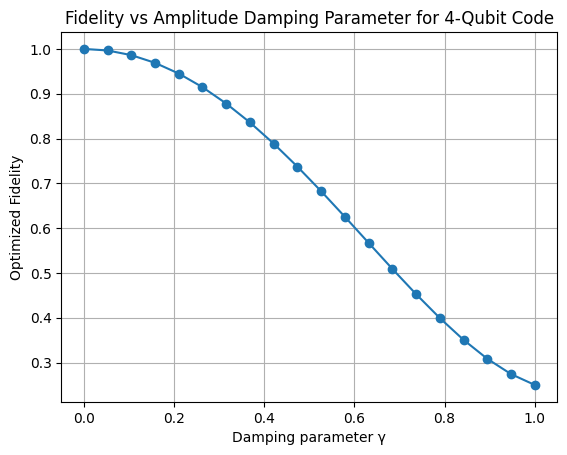

In [28]:
rho, l0, l1 = four_qubit(return_qutip=False)
gamma = np.linspace(0,1,20)
fid = []
dim = rho.shape[0]
for g in gamma:
    kraus = local_ampdamp(g, dim)
    fidelity = optimise(qutip.Qobj(l0), qutip.Qobj(l1), [qutip.Qobj(k) for k in kraus], 
    solver = 'mosek')
    fid.append(fidelity)
plt.plot(gamma, fid, marker='o')
plt.xlabel('Damping parameter γ')
plt.ylabel('Optimized Fidelity')
plt.title('Fidelity vs Amplitude Damping Parameter for 4-Qubit Code')
plt.grid()    



 done for gamma value: 0.00001 
 done for gamma value: 0.00001 
 done for gamma value: 0.00002 
 done for gamma value: 0.00003 
 done for gamma value: 0.00004 
 done for gamma value: 0.00006 
 done for gamma value: 0.00009 
 done for gamma value: 0.00013 
 done for gamma value: 0.00018 
 done for gamma value: 0.00026 
 done for gamma value: 0.00038 
 done for gamma value: 0.00055 
 done for gamma value: 0.00078 
 done for gamma value: 0.00113 
 done for gamma value: 0.00162 
 done for gamma value: 0.00234 
 done for gamma value: 0.00336 
 done for gamma value: 0.00483 
 done for gamma value: 0.00695 
 done for gamma value: 0.01000 


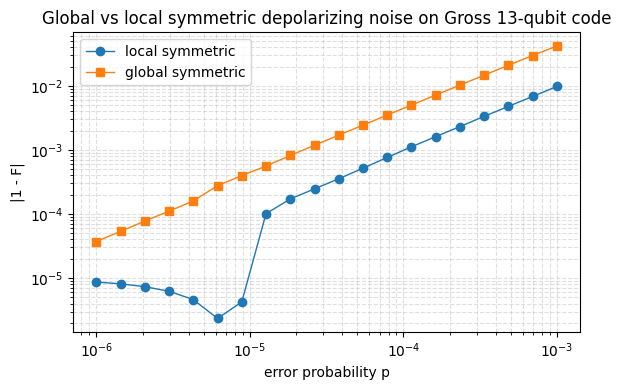

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from codewords import gross_13
from noisemodel import noisemodel
from optimisation import optimise 

rho, l0, l1 = gross_13(phi=0.0)
gamma = np.logspace(-5, -2, 20)
dt = 0.1

infids_local = []
infids_global = []

for g in gamma:
    kraus_global = noisemodel('global symmetric depolarizing', 13, g, dt)
    kraus_local = noisemodel('local symmetric depolarizing', 13, g, dt)

    fid_local = optimise(l0, l1, kraus_local, solver='mosek')
    fid_global = optimise(l0, l1, kraus_global, solver='mosek')
    print(f" done for gamma value: {g:.5f} ")

    infids_local.append(abs(1.0 - float(fid_local)))
    infids_global.append(abs(1.0 - float(fid_global)))

infids_local = np.array(infids_local, dtype=float)
infids_global = np.array(infids_global, dtype=float)
p_vals = gamma * dt

# avoid log(0)
mask_local = infids_local > 0
mask_global = infids_global > 0

plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask_local], infids_local[mask_local], "o-", lw=1, label="local symmetric")
plt.loglog(p_vals[mask_global], infids_global[mask_global], "s-", lw=1, label="global symmetric")
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local symmetric depolarizing noise on Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


I will compare the bgm code's global symmetric plots with matlab's. 
The key difference here is block diagonal representation, use of PIQS(which shouldnt matter), and mosek solver in cvxpy. 

I will compare the 3,3,1 bgm code (that corrects 1 error) with 5,5,2 bgm code (that can correct 2 errors) and 7,7,3 (that can correct 3 error). 


Processing (b,g,m)=(3,3,2), N=15 qubits
Processing gamma=1.00e-05
  Global kraus in 19.30s
  Global optimise in 95.03s
  Local kraus in 16.69s
  Local optimise in 104.94s
Processing gamma=2.15e-05
  Global kraus in 16.99s
  Global optimise in 94.39s
  Local kraus in 17.28s
  Local optimise in 94.62s
Processing gamma=4.64e-05
  Global kraus in 17.27s
  Global optimise in 121.72s
  Local kraus in 17.98s
  Local optimise in 94.29s
Processing gamma=1.00e-04
  Global kraus in 22.03s
  Global optimise in 129.97s
  Local kraus in 17.51s
  Local optimise in 117.76s
Processing gamma=2.15e-04
  Global kraus in 21.63s
  Global optimise in 130.78s
  Local kraus in 17.25s
  Local optimise in 110.01s
Processing gamma=4.64e-04
  Global kraus in 21.22s
  Global optimise in 123.90s
  Local kraus in 21.15s
  Local optimise in 127.03s
Processing gamma=1.00e-03
  Global kraus in 21.67s
  Global optimise in 108.30s
  Local kraus in 22.87s
  Local optimise in 122.47s
Processing gamma=2.15e-03
  Global krau

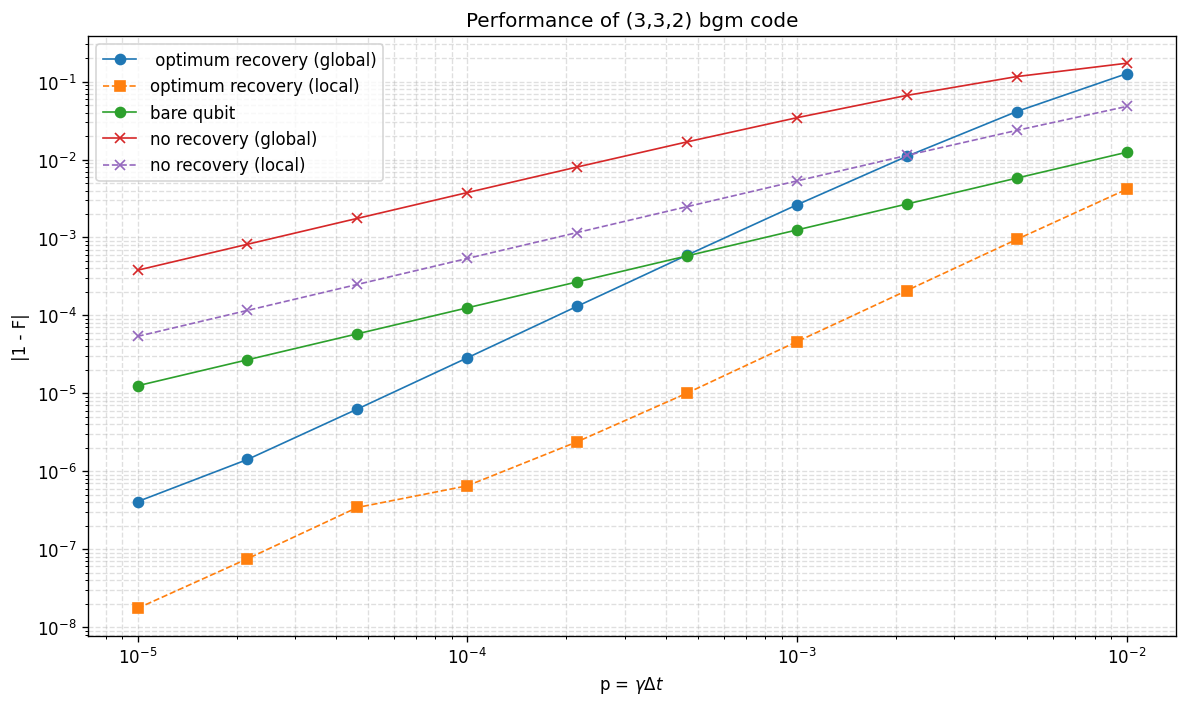

In [10]:
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"

import qutip
import matplotlib
from qutip.piqs.piqs import *
import numpy as np
from noisemodel import *
from codewords import *
from optimisation import *
import matplotlib.pyplot as plt
import time
import gc  # garbage collection

# Compare (b,g,m) codes against global depolarizing noise
#codes = [(3, 3, 2), (5, 5, 2)]
codes = [(3, 3, 2)]
gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi = 120)

#bare qubit for comparison
rho_bare = 0.5 * qeye(2)
infids_bare_global = []

#method: kraus or choi
method = 'choi'
method_norecovery = 'kraus'

for b, g_code, m in codes:
    N = 2 * b * m + g_code
    print(f"\n{'='*60}")
    print(f"Processing (b,g,m)=({b},{g_code},{m}), N={N} qubits")
    print(f"{'='*60}")
    
    rho, l0, l1 = bgmcode_piqs(b, g_code, m, return_qutip=True)
    infids_global = []
    infids_local = []
    infids_norecovery_global = []
    infids_norecovery_local = []
    
    for g in gamma:
        print(f"Processing gamma={g:.2e}")

        try:
            # Global depolarizing
            t0 = time.perf_counter()
            kraus_global = noisemodel('global symmetric depolarizing', N, g, dt, method)
            t1 = time.perf_counter()
            print(f"  Global kraus in {t1 - t0:.2f}s")

            fid_global = optimise(l0, l1, kraus_global, solver='mosek')
            t2 = time.perf_counter()
            print(f"  Global optimise in {t2 - t1:.2f}s")
            
            infids_global.append(abs(1.0 - float(fid_global)))

            #bgm code without recovery operation
            infids_norecovery_global.append(abs(1.0 - float(no_recovery(rho, noisemodel('global symmetric depolarizing',N, g, dt, method_norecovery)))))

            #bare qubit infidelity for comparison
            fid_bare_global = optimise(qutip.basis(2,0), qutip.basis(2,1), noisemodel('global symmetric depolarizing',1,g,dt,method))
            infids_bare_global.append(abs(1.0 - float(fid_bare_global)))
            
            # Delete large objects immediately after use
            del kraus_global
            gc.collect()  # Force garbage collection
            
        except Exception as e:
            print(f"  ERROR (global): {e}")
            infids_global.append(np.nan)

        try:
            # Local depolarizing
            t3 = time.perf_counter()
            kraus_local = noisemodel('local symmetric depolarizing', N, g, dt, method)
            t4 = time.perf_counter()
            print(f"  Local kraus in {t4 - t3:.2f}s")

            fid_local = optimise(l0, l1, kraus_local, solver='mosek')
            t5 = time.perf_counter()
            print(f"  Local optimise in {t5 - t4:.2f}s")
            
            infids_local.append(abs(1.0 - float(fid_local)))

            #bgm code without recovery operation
            infids_norecovery_local.append(abs(1.0 - float(no_recovery(rho, noisemodel('local symmetric depolarizing',N, g, dt, method_norecovery)))))
            
            # Delete large objects immediately after use
            del kraus_local
            gc.collect()  # Force garbage collection
            
        except Exception as e:
            print(f"  ERROR (local): {e}")
            infids_local.append(np.nan)

    # Process results
    infids_global = np.array(infids_global, dtype=float) #bgm code after recovery
    infids_bare_global = np.array(infids_bare_global, dtype=float) #bare qubit
    infids_local = np.array(infids_local, dtype=float) #bgm code after recovery
    infids_norecovery_global = np.array(infids_norecovery_global, dtype=float)#bgm code without recovery
    infids_norecovery_local = np.array(infids_norecovery_local, dtype=float)#bgm code without recovery
    
    mask_global = (infids_global > 0) & np.isfinite(infids_global)
    mask_local = (infids_local > 0) & np.isfinite(infids_local)
    mask_bare_global = (infids_bare_global > 0) & np.isfinite(infids_bare_global)
    mask_infids_norecovery_global = (infids_norecovery_global > 0) & np.isfinite(infids_norecovery_global)
    mask_infids_norecovery_local = (infids_norecovery_local > 0) & np.isfinite(infids_norecovery_local)
    
    if np.any(mask_global):
        #plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f"bgm ({b},{g_code},{m}) optimum recovery (global)")
        plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f" optimum recovery (global)")
    if np.any(mask_local):
        #plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"bgm ({b},{g_code},{m}) optimum recovery (local)")
        plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"optimum recovery (local)")
    if np.any(mask_bare_global):
        plt.loglog(p_vals[mask_bare_global], infids_bare_global[mask_bare_global], "o-", lw=1, label="bare qubit")
    if np.any(mask_infids_norecovery_global):
        #plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"bgm ({b},{g_code},{m}) no recovery (global)")
        plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"no recovery (global)")
    if np.any(mask_infids_norecovery_local):
        #plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"bgm ({b},{g_code},{m}) no recovery (local)")
        plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"no recovery (local)")

    # Clean up large objects for this code
    del rho, l0, l1, infids_global, infids_local, infids_bare_global, infids_norecovery_global, infids_norecovery_local
    gc.collect()

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Performance of (3,3,2) bgm code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

compare 331 and 332 bgm code 

bgm(3,3,1): N=9, gamma=1.0e-05 -> F_opt=1.000000
bgm(3,3,1): N=9, gamma=5.0e-05 -> F_opt=0.999999
bgm(3,3,1): N=9, gamma=1.0e-04 -> F_opt=0.999995
bgm(3,3,1): N=9, gamma=5.0e-04 -> F_opt=0.999868
bgm(3,3,1): N=9, gamma=1.0e-03 -> F_opt=0.999482
bgm(3,3,1): N=9, gamma=5.0e-03 -> F_opt=0.988684
bgm(3,3,2): N=15, gamma=1.0e-05 -> F_opt=1.000000
bgm(3,3,2): N=15, gamma=5.0e-05 -> F_opt=0.999993
bgm(3,3,2): N=15, gamma=1.0e-04 -> F_opt=0.999971
bgm(3,3,2): N=15, gamma=5.0e-04 -> F_opt=0.999314
bgm(3,3,2): N=15, gamma=1.0e-03 -> F_opt=0.997377
bgm(3,3,2): N=15, gamma=5.0e-03 -> F_opt=0.953470


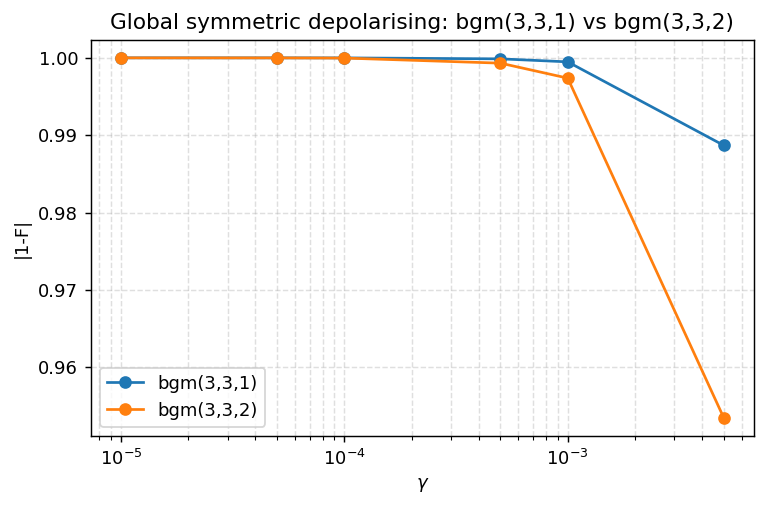

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from codewords import bgmcode_piqs
from noisemodel import noisemodel
from optimisation import optimise

# two test points (pick any two you like)
gamma_vals = np.array([1e-5, 5e-5,1e-4,5e-4,1e-3, 5e-3])
dt = 1.0
method = "choi"  # global symmetric depolarizing supports "choi" in your code

#codes = [(3, 3, 1), (3, 3, 2)]
codes = [5, 5, 2]
labels = ["bgm(3,3,1)", "bgm(3,3,2)"]

fids = {lab: [] for lab in labels}

for (b, g, m), lab in zip(codes, labels):
    N = 2 * b * m + g
    rho, l0, l1 = bgmcode_piqs(b, g, m, return_qutip=True)

    for gamma in gamma_vals:
        kraus_or_choi = noisemodel("global symmetric depolarizing", N, gamma, dt, method)
        F = float(optimise(l0, l1, kraus_or_choi, solver="mosek"))
        fids[lab].append(F)
        print(f"{lab}: N={N}, gamma={gamma:.1e} -> F_opt={F:.6f}")

# plot (2 points per curve)
plt.figure(figsize=(6, 4), dpi=130)
for lab in labels:
    plt.plot(gamma_vals, fids[lab], "o-", label=lab)

plt.xscale("log")
plt.xlabel(r"$\gamma$")
plt.ylabel("|1-F|")
plt.title("Global symmetric depolarising: bgm(3,3,1) vs bgm(3,3,2)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

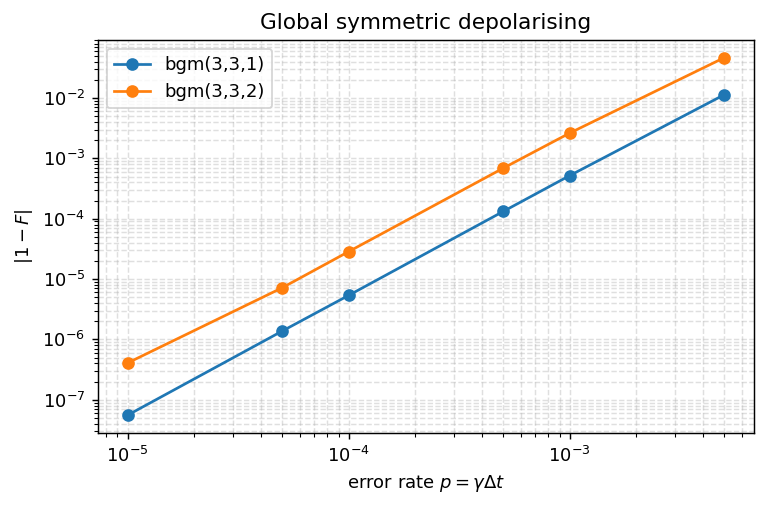

In [17]:
# assume: gamma_vals (array), dt (float), and fids dict from your loop

p_vals = gamma_vals * dt

plt.figure(figsize=(6, 4), dpi=130)
for lab in labels:
    F = np.array(fids[lab], dtype=float)
    infid = np.abs(1.0 - F)
    mask = (infid > 0) & np.isfinite(infid)  # avoid log(0) / nan
    plt.loglog(p_vals[mask], infid[mask], "o-", label=lab)

plt.xlabel(r"error rate $p=\gamma\Delta t$")
plt.ylabel(r"$|1-F|$")
plt.title("Global symmetric depolarising")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

non-markovian channel

In [2]:
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/a46668993/Desktop/qer/mosek/mosek.lic"

import qutip
import matplotlib
from qutip.piqs.piqs import *
import numpy as np
from noisemodel import *
from codewords import *
from optimisation import *
import matplotlib.pyplot as plt
import time
from non_markovian import choi

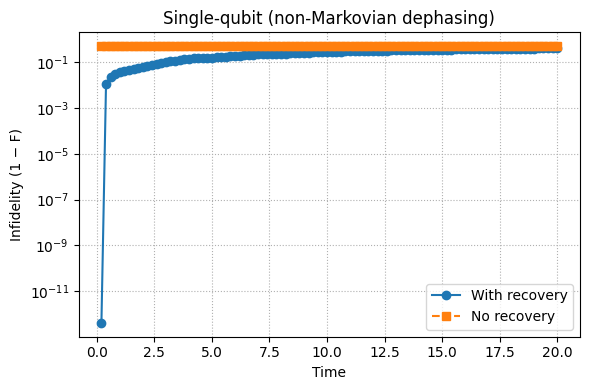

In [14]:
# initiating a single-qubit system
l0 = qutip.basis(2, 0)
l1 = qutip.basis(2, 1)
rho = 0.5 * (l0*l0.dag() + l1*l1.dag())

# decay rate function γ(t)
epsilon = 0.5
gamma_func = lambda t: 1/6 + ((1 - epsilon) * np.cos(2 * t)) / 6

# time grid (THIS is what integrated_rate wants)
times = np.linspace(0.2, 20, 100)

# generate all Choi matrices at once
N = 1
choi_list, _ = choi(
    N=N,
    times=times,
    gamma=gamma_func
)

# evaluate figures of merit
fid = []
fid_no = []

for choi_t in choi_list:
    fid.append(optimise(l0, l1, choi_t, solver="mosek"))
    fid_no.append(no_recovery(rho, choi_t))

import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
times = np.asarray(times)
fid = np.asarray(fid)
fid_no = np.asarray(fid_no)

# Infidelities
infid = np.abs(1.0 - fid)
infid_no = np.abs(1.0 - fid_no)

# Avoid log(0) issues (numerical floor)
eps = 1e-14
infid = np.clip(infid, eps, None)
infid_no = np.clip(infid_no, eps, None)

# Plot
plt.figure(figsize=(6, 4))
plt.semilogy(times, infid, 'o-', label='With recovery')
plt.semilogy(times, infid_no, 's--', label='No recovery')

plt.xlabel('Time')
plt.ylabel('Infidelity (1 − F)')
plt.title('Single-qubit (non-Markovian dephasing)')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()



veryfying the performance of Gross's 13/2 qubit code

In [12]:
import numpy as np
import qutip as qt


def gross13_codewords(phi=0.0, block_irrep=True, return_qutip=True):
    """
    Gross codewords for N=13 (j=13/2) and the maximally mixed logical state
      rho = (|0><0| + |1><1|)/2

    Args:
      phi         : phase in Eq.(22)
      block_irrep : True -> embed in 56-dim one-copy-per-J irrep-block basis
                    False -> return in maximal-J Dicke basis (dim = 14)
      return_qutip: True -> return QuTiP Qobj; False -> NumPy arrays

    Returns:
      (logical0, logical1, rho) in the chosen basis.
    """
    N = 13
    j = N / 2
    dJ = int(2 * j + 1)  # 14

    def ket_m(m):
        v = np.zeros((dJ, 1), dtype=complex)
        v[int(round(m + j)), 0] = 1.0  # m order: -j..+j
        return v

    # Eq.(20)
    ket0_a = (
        np.sqrt(910)/56 * ket_m(13/2)
        - 3*np.sqrt(154)/56 * ket_m(5/2)
        - np.sqrt(770)/56 * ket_m(-3/2)
        + np.sqrt(70)/56 * ket_m(-11/2)
    )

    # Eq.(21)
    ket0_b = (
        np.sqrt(231)/84 * ket_m(13/2)
        + np.sqrt(1365)/84 * ket_m(5/2)
        - np.sqrt(273)/28 * ket_m(-3/2)
        - np.sqrt(3003)/84 * ket_m(-11/2)
    )

    # Eq.(22)
    #ket0 = np.sqrt(105/14) * ket0_a + np.exp(1j * phi) * np.sqrt(91/14) * ket0_b
    a = np.sqrt(13/7)/2
    ket0 = a*ket0_a + np.exp(1j*phi)*np.sqrt(1-a**2)*ket0_b
    ket0 /= np.linalg.norm(ket0)
    ket0_q = qt.Qobj(ket0, dims=[[dJ], [1]])

    # logical-1: exp(-i π Jx) |0>
    Jx = qt.jmat(j, 'x')
    ket1_q = (-1j * np.pi * Jx).expm() * ket0_q

    # choose representation
    if not block_irrep:
        logical0, logical1 = ket0_q, ket1_q
        rho = 0.5 * (logical0 * logical0.dag() + logical1 * logical1.dag())

        if return_qutip:
            return logical0, logical1, rho
        return logical0.full(), logical1.full(), rho.full()

    # embed into 56-dim one-copy-per-J basis
    block_dims = [14, 12, 10, 8, 6, 4, 2]
    D = sum(block_dims)  # 56

    big0 = np.zeros((D, 1), dtype=complex)
    big1 = np.zeros((D, 1), dtype=complex)
    big0[:dJ, 0] = ket0_q.full().ravel()
    big1[:dJ, 0] = ket1_q.full().ravel()

    logical0 = qt.Qobj(big0, dims=[[D], [1]])
    logical1 = qt.Qobj(big1, dims=[[D], [1]])
    rho = 0.5 * (logical0 * logical0.dag() + logical1 * logical1.dag())

    if return_qutip:
        return rho, logical0, logical1
    return rho.full(), logical0.full(), logical1.full()


In [1]:
from codewords import gross_13_kets_in_top_block, gross_13_piqs
logical0, _, _  = gross_13_kets_in_top_block(phi=0.0)

In [3]:
import qutip
logical0, _, _  = gross_13_kets_in_top_block(phi=0.0)
Jz = qutip.jmat(13/2, 'z')

val = (logical0.dag() * (Jz * logical0))
print(val)


(-2.220446049250313e-16+0j)
